# MJD: classify Majorana detector waveforms

Follow one saved experiment from local data to a three-iteration research search and its recorded AUC. Your notebook explains and edits files in an **external project**; the saved shell script owns native execution. Complete the [setup guide](https://github.com/yuema137/siderius-exp/blob/main/tutorials/supplementary/mjd/README.md) first.


One sample is a 3,800-value `raw_waveform`. The task subtracts the mean of the first 500 samples and divides by their standard deviation, floored at one ADC unit. The model receives `[B,1,3800]` float32 and returns two raw logits `[rejected, accepted]`; target `psd_label_low_avse` says whether the event passes the Low-AvsE cut. Energy, identifiers, detector/run metadata, timing and other labels are **not model inputs**.

The official **16 Train files feed training; 6 Test files feed evaluation during agent search**. The agent can use these evaluation results to choose later models. Consequently this Test partition is **not a blind final holdout**. Three unlabeled NPML files are excluded. This tutorial preserves those partitions; changing a fraction does not resplit them.
The images below are archived outputs from the [recorded three-iteration demo](https://github.com/yuema137/siderius-exp/blob/main/tutorials/supplementary/mjd/example/README.md), executed with exp `9fc82f9` and infra `52373be`. The waveform is a CPU data preview; the score chart comes from actual training records. Initialization clears these outputs from your copy, which then uses your own saved project.

## Hardware before Run All

Training needs one supported NVIDIA GPU, the paired CUDA environment and working driver memory accounting. CPU machines can inspect data or plot existing results, but cannot run this training demo. AMD/ROCm remains experimental and currently lacks the accounting required by this route; Intel GPU training is unsupported. Select one device with `CUDA_VISIBLE_DEVICES` before starting Jupyter.

The shipped short demo sets a **10 GiB VRAM allowance**. The GPU must have greater physical capacity, and its current occupied memory plus the larger saved Trial/Formal allowance must fit within the device/deployment limit. This is a configured allowance, not a measured model minimum. Lowering it does not make every generated model fit.

The 22 original supervised files total about 43.5 GB. Reuse them in place; selected waveforms and outputs require additional host memory and storage. No universal training host-RAM minimum has been qualified. The hardware report shows host RAM and output-filesystem space as observations, not a guarantee of sufficient memory for this workload.

**Check without paying or training:** Project initialization creates this JSON. If you select a saved variant, replace the filename with the selected JSON printed by the notebook.

```bash
cd /absolute/path/siderius-exp
.venv/bin/python -m tutorials.shared.hardware \
  --experiment "$TUTORIAL_HOME/experiments/mjd-demo.json"
```

This hardware-only command needs no API key and creates no run workspace; it queries the GPU and runs a tiny kernel. It does not replace task/data/configuration review. Fresh Run All launches repeat the GPU check automatically before provider calls. A pass does not reserve memory or prove that a future generated model fits; native measurement and monitoring still apply. Set `RUN_QUICK_DEMO=False` for a CPU/offline walkthrough. See the [hardware setup guide](https://github.com/yuema137/siderius-exp/blob/main/tutorials/shared/hardware/README.md) for limits and corrective steps.


## 1. Open your saved project

The following cell checks `TUTORIAL_HOME` and your exp kernel. Select a saved experiment by name; it never rewrites your JSON with notebook defaults. Inspect all paths printed below. Credentials belong in the terminal environment that started Jupyter, never in this notebook.

In [ ]:
import json
import os
import sys
from pathlib import Path

home = os.environ.get("TUTORIAL_HOME")
if not home:
    raise RuntimeError(
        "Export TUTORIAL_HOME to your initialized external project and restart Jupyter."
    )
PROJECT = Path(home).expanduser().resolve()
if not (PROJECT / "project.json").is_file():
    raise RuntimeError(
        "Missing project.json; initialize a new external MJD project using the README."
    )
binding = json.loads((PROJECT / "project.json").read_text())
EXP_CHECKOUT = Path(binding["exp_checkout"])
if Path(sys.prefix).resolve() != (EXP_CHECKOUT / ".venv").resolve():
    raise RuntimeError(
        "Select the SIDERIUS MJD tutorial kernel from this exp checkout."
    )
sys.dont_write_bytecode = True
os.chdir(EXP_CHECKOUT)
from IPython.display import Markdown, display

from tutorials.supplementary.mjd.data import scope_counts, show_waveform
from tutorials.supplementary.mjd.demo import plot_results, review, run_demo
from tutorials.supplementary.mjd.project import save_variant
from tutorials.supplementary.mjd.settings import MjdExperiment

SELECTED_EXPERIMENT = "mjd-demo"  # Or your saved variant name.
EXPERIMENT = PROJECT / "experiments" / f"{SELECTED_EXPERIMENT}.json"
SCRIPT = (
    PROJECT
    / "scripts"
    / (
        "run-mjd.sh"
        if SELECTED_EXPERIMENT == "mjd-demo"
        else f"run-{SELECTED_EXPERIMENT}.sh"
    )
)
settings = MjdExperiment.model_validate_json(EXPERIMENT.read_text())
print(
    f"Project: {PROJECT}\nExperiment: {EXPERIMENT}\nScript: {SCRIPT}\nRaw data: {settings.data_dir}\nFresh run workspace: {settings.workspace}"
)

## 2. See actual data and actual selected counts

Fractions select a deterministic snapshot within each official partition. Then the task retains equal rejected/accepted counts **inside each fixed 25-keV energy bin**, between 0 and 5,000 keV. A bin with only one class contributes no examples. Energy is used for matching and scoring, never passed to the model. Cross entropy trains the two logits; the primary metric is energy-matched ROC AUC (higher is better), with ordinary AUC reported separately.

For example, a selected bin containing 9 rejected and 3 accepted events retains 3 of each, not 12. That arithmetic explains why selected counts are not simply `fraction × total`. The next cell asks the actual copied task loader for counts with illustrative seed 42. A real attempt can use a different seed. The per-epoch `train_portion` is fixed at 1, so there is no second thinning stage in this demo.

All 22 official files remain required (~43.5 GB); tiny training fractions do not reduce source downloads or full-partition metadata reads. This CPU-only preview checks filenames and sizes, not full file integrity. Launch independently verifies all 22 official files before training. The waveform figure reads **Train only** and uses the selected task's actual normalization.

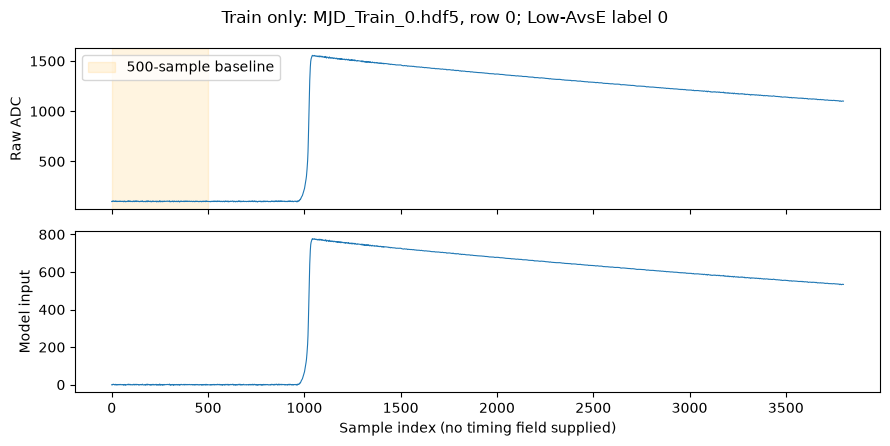

In [ ]:
settings = MjdExperiment.model_validate_json(EXPERIMENT.read_text())
counts = scope_counts(settings)
rows = "\n".join(
    f"| {c.name} | {c.official_role} | {c.fraction:g} | {c.samples} | {c.rejected} | {c.accepted} |"
    for c in counts
)
display(
    Markdown(
        "| Scope (seed 42) | Official role | Fraction | Actual selected | Rejected | Accepted |\n|---|---|---|---|---|---|\n"
        + rows
    )
)
PREVIEW_ROW = 0
figure = show_waveform(settings, row=PREVIEW_ROW)
display(figure)

## 3. Change a saved experiment

Edit only your external project. `tasks/mjd/compositions/low_avse.yaml` selects the data plugin, metric and model contract; `tasks/mjd/declared/dataset_manifest.json` identifies official bytes and must match the source authority. The copied plugins own waveform processing and partition membership. Scientific changes need a separately identified task; there is no resplit exercise here.

`experiments/mjd-demo.json` owns run choices. `llm/agents.json` owns model/provider/planner routing (initially the native GPT-6 Luna test profile). `experiments/workflow.json` owns the fixed workflow. Data Analysis, literature review and human advice are disabled. `advice_file` cannot be activated in this treatment.

| JSON knob | Initial value | Effect |
|---|---:|---|
| `iterations` | 3 | Research cycles; `rounds=2` provides Trial then Formal within each |
| `epochs` | 1 | Maximum epochs per attempt, not a promised count |
| `trial_train_fraction`, `formal_train_fraction` | .01, .01 | Snapshot of official Train before balancing; range .01–1 |
| `trial_eval_fraction`, `formal_eval_fraction` | .01, .01 | Snapshot of official Test used for search feedback; range .01–1 |
| `train_portion` | 1 | Fixed: retain the selected training scope each epoch |
| `trial_minutes`, `formal_minutes` | 2, 5 | Native per-attempt training allowances; not total API or wall-time caps |
| `vram_gib` | 10 | Shared per-round VRAM budget; optional `trial_vram_gib` / `formal_vram_gib` override it |
| `gpu` | null | Auto-detect the visible logical GPU; a string requires that name |
| `data_dir`, `infra_checkout`, `workspace` | absolute paths | Existing data/framework and fresh run output; workspace is not the project root |

The optional save-as cell makes a **new JSON/script/run-name pair**. It never overwrites an earlier experiment. Use one example at a time: `{"iterations": 4}`; `{"trial_minutes": 3, "formal_minutes": 6}`; or `{"trial_train_fraction": 0.01, "formal_train_fraction": 0.02}`. Save only; nothing trains here. After saving, disable `SAVE_VARIANT` and select that name in section 1 to review/run it. Increasing iterations changes planned work; increasing budgets alone does not guarantee a better AUC.

In [ ]:
SAVE_VARIANT = False
VARIANT_NAME = "mjd-four-001"
CHANGES = {"iterations": 4}
if SAVE_VARIANT:
    new_experiment, new_script = save_variant(
        PROJECT, EXPERIMENT, name=VARIANT_NAME, changes=CHANGES
    )
    print(
        f"Saved: {new_experiment}\nScript: {new_script}\nSelect {VARIANT_NAME!r} in section 1 before running it."
    )
else:
    print("Using the selected saved JSON unchanged. Save-as is disabled.")

## 4. Inspect exactly what the script will read

Re-read the saved experiment, script bindings and data filenames below. Check the task, official manifest, LLM routing, workflow, fractions, budgets and fresh workspace. A name-only key check says whether a key is present, not whether the provider will accept it. If you changed environment variables after starting Jupyter, restart its server from the correct terminal.

The optional native preview resolves the exact exp/framework/planner identities and prints native arguments without API or GPU work. It needs both frozen environments. Set `RUN_NATIVE_PREVIEW=False` only for an explicitly offline file walkthrough; actual launch always repeats its checks.

In [ ]:
display(Markdown(review(EXPERIMENT, SCRIPT)))
RUN_NATIVE_PREVIEW = True
preview_settings = MjdExperiment.model_validate_json(EXPERIMENT.read_text())
if RUN_NATIVE_PREVIEW and preview_settings.workspace.exists():
    print(
        "Workspace exists: native launch preview skipped. Section 5 checks completed-result reuse; section 6 plots records independently."
    )
elif RUN_NATIVE_PREVIEW:
    import subprocess

    subprocess.run(["bash", str(SCRIPT)], check=True)
else:
    print("Native preview skipped; this is not launch qualification.")

## 5. Run the saved script — API and GPU effects

**Run All reaches this cell and, when `RUN_QUICK_DEMO=True`, invokes the displayed saved script with `--launch`.** It spends provider credit and GPU time. The initial file asks for exactly three iterations. A saved four-iteration variant asks for four. Inspect the saved JSON before enabling a launch; these settings are not a whole-run spending cap.

`RUN_QUICK_DEMO=False` skips live execution. The launcher checks source pins, exported keys, GPU readiness and the integrity of all 22 official files before native execution. File verification reads ~43.5 GB and adds preparation time. The notebook timeout starts before the saved script, includes this verification and stops its process tree; it is not API billing or GPU accounting.

Completed unchanged inputs reuse their recorded result without API/GPU checks. Changed task/routing/workflow/script/experiment/source identity requires a fresh run name. Interrupted or failed runs preserve logs and refuse silent relaunch; inspect them and use section 6 independently. Do not extend the search merely to obtain a successful or high-scoring model.

In [ ]:
RUN_QUICK_DEMO = True
NOTEBOOK_TIMEOUT_SECONDS = 3600
if RUN_QUICK_DEMO:
    result = run_demo(EXPERIMENT, SCRIPT, timeout_seconds=NOTEBOOK_TIMEOUT_SECONDS)
    print(result)
else:
    print("Live search disabled: no saved script launched, no API/GPU work.")

## 6. Plot recorded results independently

This cell can be run alone after setup imports. Set `PLOT_EXPERIMENT` to an existing run's saved JSON and `PLOT_OUTPUT` to an external plot directory; it does not require credentials, raw data, native preview or a new launch. Missing records are not fabricated. If there is no finite Formal score, it reports that limitation instead of making a placeholder chart.

The plot reads actual native `metric_result.scalar` values from Formal attempts. Trial results are not substitutes. Failed attempts with a measured AUC remain visible with open markers; unscored attempts remain in the CSV. The running-best raw-score line can include rejected attempts: it is not an accepted-model ranking.

**This task explicitly has no Health checks.** Filled/star markers mean a scored successful execution under that no-Health declaration, not a measured Health PASS or scientific validation. `validity=pass` in the shared CSV has that same limited meaning. The x-axis is outer research iteration, not epoch. Files are PNG, SVG and CSV with native record paths. There is no promised upward trajectory.

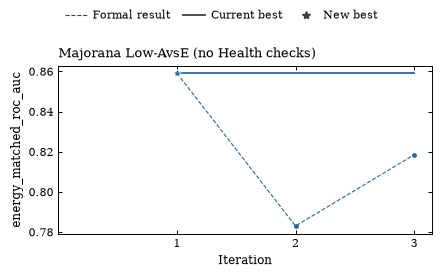

In [ ]:
PLOT_EXPERIMENT = (
    EXPERIMENT  # Or Path("/absolute/project/experiments/earlier-run.json")
)
PLOT_OUTPUT = PROJECT / "plots" / PLOT_EXPERIMENT.stem
plot_settings = MjdExperiment.model_validate_json(PLOT_EXPERIMENT.read_text())
if plot_settings.workspace.is_dir():
    try:
        display(plot_results(PLOT_EXPERIMENT, PLOT_OUTPUT))
        print(f"Saved PNG/SVG/CSV to {PLOT_OUTPUT}")
    except ValueError as error:
        print(f"Plot unavailable: {error}")
else:
    print(
        "No result workspace yet. Run the saved script when authorized, or select an existing PLOT_EXPERIMENT."
    )